<a href="https://colab.research.google.com/github/takeonakamura6-design/so/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Gerenciamento de memória U4-S1

=== RESULTADOS DO EXPERIMENTO DE GERENCIAMENTO DE MEMÓRIA ===
             Métrica   FIFO    LRU
Total de Requisições     20     20
 Capacidade (Frames)      3      3
Page Faults (Falhas)     15     12
   Taxa de Falha (%) 75.00% 60.00%




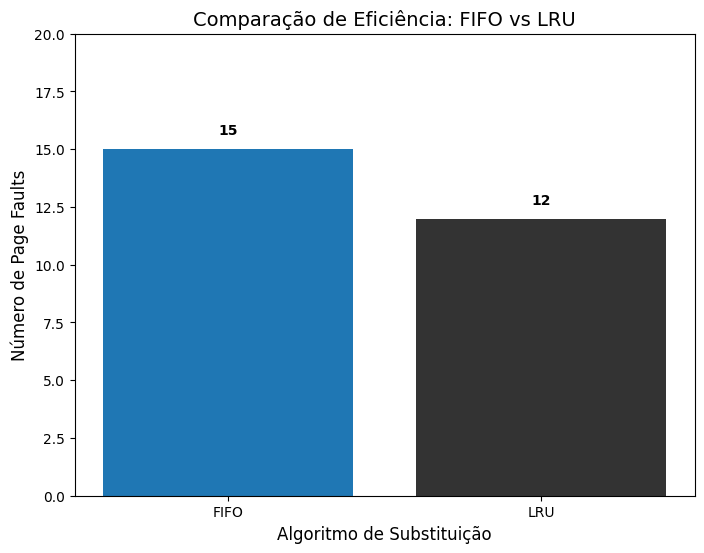

Sucesso: 'grafico.png' gerado e pronto para publicação no Zenodo.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def simular_fifo(referencias, frames):
    memoria = []
    falhas = 0
    for pagina in referencias:
        if pagina not in memoria:
            if len(memoria) < frames:
                memoria.append(pagina)
            else:
                memoria.pop(0)
                memoria.append(pagina)
            falhas += 1
    return falhas

def simular_lru(referencias, frames):
    memoria = []
    falhas = 0
    for pagina in referencias:
        if pagina not in memoria:
            if len(memoria) < frames:
                memoria.append(pagina)
            else:
                memoria.pop(0)
                memoria.append(pagina)
            falhas += 1
        else:
            # Move a página acessada para o final para marcar como 'recentemente usada'
            memoria.remove(pagina)
            memoria.append(pagina)
    return falhas

def executar_experimento():
    # Configurações do Experimento
    referencias = [7, 0, 1, 2, 0, 3, 0, 4, 2, 3, 0, 3, 2, 1, 2, 0, 1, 7, 0, 1]
    capacidade = 3

    # Execução
    falhas_fifo = simular_fifo(referencias, capacidade)
    falhas_lru = simular_lru(referencias, capacidade)

    total_requisicoes = len(referencias)
    taxa_fifo = (falhas_fifo / total_requisicoes) * 100
    taxa_lru = (falhas_lru / total_requisicoes) * 100

    # Criação do DataFrame para exibição
    dados = {
        'Métrica': ['Total de Requisições', 'Capacidade (Frames)', 'Page Faults (Falhas)', 'Taxa de Falha (%)'],
        'FIFO': [total_requisicoes, capacidade, falhas_fifo, f"{taxa_fifo:.2f}%"],
        'LRU': [total_requisicoes, capacidade, falhas_lru, f"{taxa_lru:.2f}%"]
    }
    df = pd.DataFrame(dados)

    # Exibição da Tabela
    print("=== RESULTADOS DO EXPERIMENTO DE GERENCIAMENTO DE MEMÓRIA ===")
    print(df.to_string(index=False))
    print("\n")

    # Geração do Gráfico
    algoritmos = ['FIFO', 'LRU']
    falhas_valores = [falhas_fifo, falhas_lru]

    plt.figure(figsize=(8, 6))
    bars = plt.bar(algoritmos, falhas_valores, color=['#1f77b4', '#333333'])
    plt.title('Comparação de Eficiência: FIFO vs LRU', fontsize=14)
    plt.ylabel('Número de Page Faults', fontsize=12)
    plt.xlabel('Algoritmo de Substituição', fontsize=12)
    plt.ylim(0, max(falhas_valores) + 5)

    # Adicionar rótulos nas barras
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom', fontweight='bold')

    # Salvar o gráfico para publicação
    plt.savefig('grafico.png')
    plt.show()
    print("Sucesso: 'grafico.png' gerado e pronto para publicação no Zenodo.")

if __name__ == "__main__":
    executar_experimento()